In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

# REIXS

In [3]:
scan_lists = [[342,345,348,351,354,357,361,364,367,370,373,377],
              [269,273,277,281,285,289,294,298,302,306,310,315],
              [187,191,195,199,203,207,212,216,220,224,228],
              [78,84,89,94,99,104,109,113,117,121,126]]
yshifts = [-0.04, -0.04, -0.04, -0.04]
edges = ['Mn', 'Fe', 'Co', 'Ni']

(0.8, 1.2)

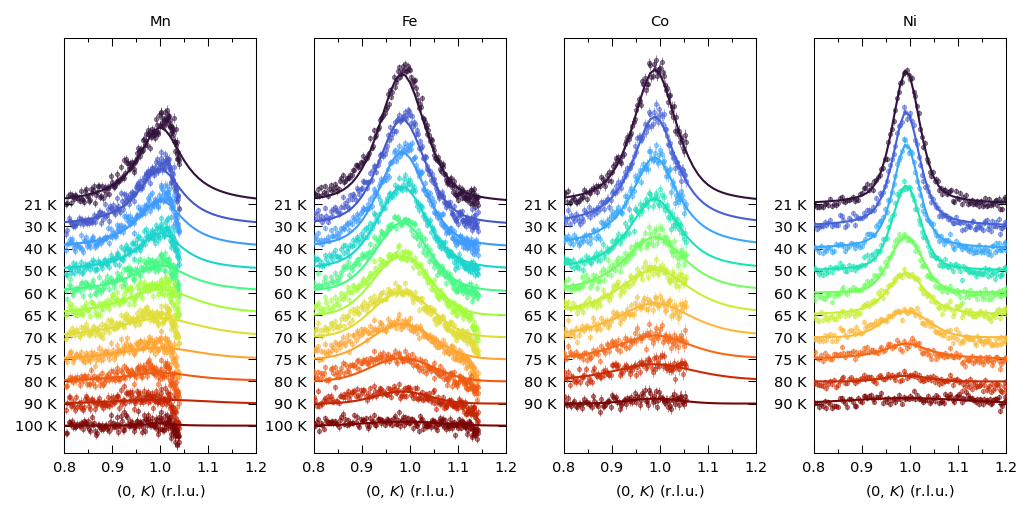

In [4]:
fig, axs = plt.subplots(1, 4, sharex=True, sharey=False, figsize=(6.75,6.75/2), dpi=150,
                        gridspec_kw=dict(wspace=0.3, left=0.05, right=0.98, bottom=0.1, top=0.92))
plot_params = dict(fmt='o', ms=2, mew=0.5, elinewidth=0.5, ls='none', alpha=0.5)

for scan_list, yshift, edge, ax in zip(scan_lists, yshifts, edges, axs):
    make_theme(ax, ticklength=4)
    ax.set_xlabel('(0, $K$) (r.l.u.)')
    ax.set_title(edge, fontsize=7)
    colors = plt.cm.turbo(np.linspace(0,1,len(scan_list)-1))
    bg1 = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_list[-1])))
    Ts = []
    for nscan, scan_no in enumerate(scan_list[:-1]):
        scan = dict(np.load('../reixs/data/rexs_{}.npz'.format(scan_no)))
        fits = dict(np.load('../reixs/fits/rexs_{}.npz'.format(scan_no)))
        fit_result = dict(np.load('../reixs/fits/results_{}.npz'.format(scan_no)))
        Ts.append(scan['T'])
        x = scan['x']
        bg2 = x * fit_result['bg_slope'][0] + fit_result['bg_intercept'][0]
        y = (scan['y'] - bg1['y']) / bg1['y'] - bg2
        yerr = np.sqrt(scan['yerr']**2 + bg1['yerr']**2) / bg1['y']
        ax.errorbar(-x, y+nscan*yshift, yerr, color=colors[nscan], zorder=nscan*10, **plot_params)
        ax.plot(-fits['x'], fits['p_']+nscan*yshift, ls='-', lw=1, color=colors[nscan], zorder=nscan*10+1)
    ax.set_yticks(np.arange(len(colors))*yshift)
    ax.set_ylim(-0.45,0.3)
    ax.set_yticklabels(['{:.0f} K'.format(T) for T in Ts])

axs[0].set_xlim(0.8,1.2)
# fig.savefig('Tdep.pdf')